<a href="https://colab.research.google.com/github/Suhail-Ahmed7/flyrank-ml-internship-suhail/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research Question

Can we use historical search-performance signals to identify content that is likely to decline in the next period?

### Decision Supported

The model is intended to help prioritize which content should be reviewed or refreshed first.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*



### Dataset
I used the FlyRank Internship dataset, which contains anonymized content-performance data. The public starter release contains 30,000 rows across 32 pseudonymized clients, while the internship workflow also supports the larger hosted warehouse release.

### Data Used
The analysis uses search-performance and content-related features such as impressions, clicks, sessions, average position, engagement rate, content age, freshness, and other non-identifying attributes.

### Label
The target is whether content is declining. The label is derived from `trend_direction`:

`is_declining_label = (trend_direction == "down")`

### Excluded Data
I excluded `trend_direction` and `trend_pct` from the model features because they are used to define the target and would cause target leakage.

I also excluded product-generated flags such as `health_score`, `needs_ctr_fix`, `is_quick_win`, and similar fields because they can leak information about the decline label.

### Public-Safety
The dataset contains pseudonymized IDs and does not expose client names, domains, URLs, page titles, keywords, or raw search queries. Public outputs are therefore limited to aggregated and anonymized results.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*


### Assumptions
The model is intended for decision support: identifying content that may need review, not predicting future performance with certainty.

### Features
I used historical search-performance and content-related features available before the prediction point, including impressions, clicks, sessions, average position, engagement rate, and relevant engineered features.

### Label
The target is:

`is_declining_label = (trend_direction == "down")`

### Baseline
I compared the machine-learning model against the transparent rule-based baseline provided in the FlyRank pipeline.

### Validation
I used a client-level holdout split, keeping approximately 20% of clients for testing. This prevents pages from the same client appearing in both training and test sets. :contentReference[oaicite:1]{index=1}

### Leakage Checks
I excluded `trend_direction` and `trend_pct` because they are used to define the target. I also excluded product-generated flags such as `health_score`, `needs_ctr_fix`, and `is_quick_win` because they can leak target information. :contentReference[oaicite:2]{index=2}

### Evaluation
The model and baseline are evaluated on the same held-out test split so their performance can be compared fairly.

In [ ]:
!python scripts/run_all.py

python3: can't open file '/content/scripts/run_all.py': [Errno 2] No such file or directory


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The models were evaluated on the same client-holdout test split containing 2,325 rows.

### Model Comparison

| Method | Precision@50 | ROC-AUC | F1 |
|---|---:|---:|---:|
| Baseline | 0.24 | 0.627 | 0.274 |
| Logistic Regression | 0.40 | 0.700 | 0.566 |
| Decision Tree | 0.58 | 0.742 | 0.634 |
| Random Forest | **0.74** | **0.750** | **0.640** |

### Best Model

Random Forest was selected as the best model because it achieved the highest Precision@50 of **0.74**.

### Interpretation

The Random Forest model identified 74% of the top-50 ranked items as declining on the held-out test set, compared with 24% for the baseline.

This is a substantial improvement in prioritization performance. The result is directional decision support and should not be interpreted as a guarantee that every predicted item will decline.

### Additional Findings

The most important Random Forest features included:

1. `days_with_impressions`
2. `log_impressions_90d`
3. `avg_position`
4. `content_age_days`
5. `char_count`

The model was trained on 30,000 rows using 52 features. The client-holdout split used 27,675 training rows and 2,325 test rows.

### Key Result

Random Forest improved Precision@50 from **0.24** with the baseline to **0.74**, showing that the learned model provides stronger prioritization of potentially declining content than the simple baseline rule.

## 5. Limitations

*What this work cannot claim.*


This work has several limitations:

- The model identifies content that is likely to be declining based on the available historical signals; it does not prove that a page will decline in the future.
- The results are based on a client-holdout evaluation split and may not generalize to every website or search environment.
- The target label is based on observed trend direction, so the model learns patterns associated with the available label rather than causation.
- Feature importance shows which features were useful for the Random Forest model, but it does not prove that those features cause content decline.
- The Random Forest Precision@50 result can vary slightly with software/library versions and environment.
- The recommendations should therefore be treated as directional decision support and should be reviewed by a human before action.

Overall, the results show a useful prioritization signal, but they should not be interpreted as a guarantee of future traffic or ranking changes.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*


The model output is intended to prioritize content for human review. The following recommendations are ranked by practical priority.

### 1. Review pages with strong decline signals
Start with pages that receive high decline-risk scores from the Random Forest model. These pages should be reviewed first because the model achieved a Precision@50 of 0.74 on the held-out test set.

### 2. Review content with weak or declining search performance
Prioritize pages with lower recent impressions, clicks, or sessions and weaker search positions. These signals were among the important features used by the model.

### 3. Review older content
Content age and days since the last update are useful signals in the model. Older pages should be reviewed for outdated information, relevance, and freshness.

### 4. Review pages with lower engagement
Pages with weaker engagement-related signals can be prioritized for human review to determine whether content quality, relevance, or user experience needs improvement.

### 5. Use human review before making changes
The model should be used as a prioritization tool, not as an automatic decision-maker. A human should review the page and decide whether to refresh, improve, monitor, or leave it unchanged.

### Action Playbook

| Priority | Action |
|---|---|
| 1 | Review high-risk pages |
| 2 | Investigate weak search-performance signals |
| 3 | Check older or stale content |
| 4 | Review engagement signals |
| 5 | Apply changes only after human review |

These recommendations are directional decision support. They do not guarantee that a page will decline or that a recommended change will improve performance.

Top Reason Codes


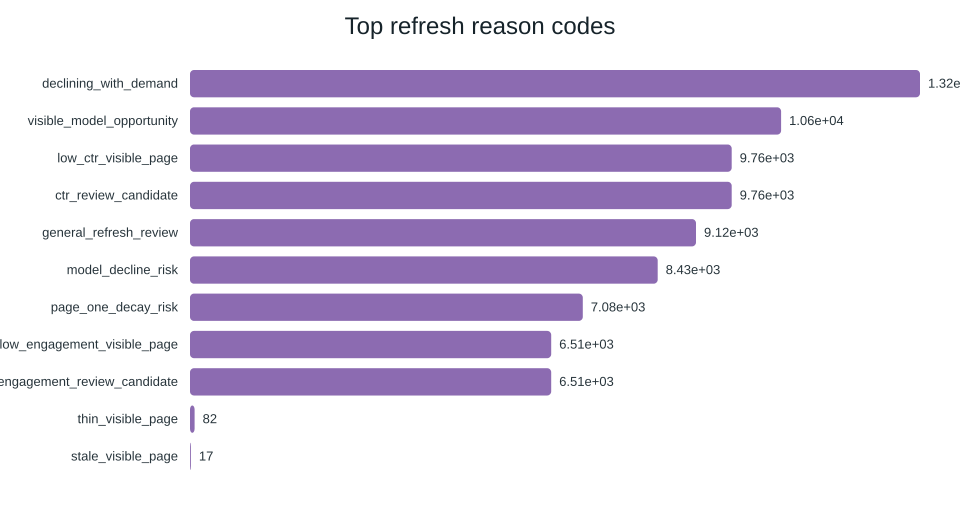

Action Mix


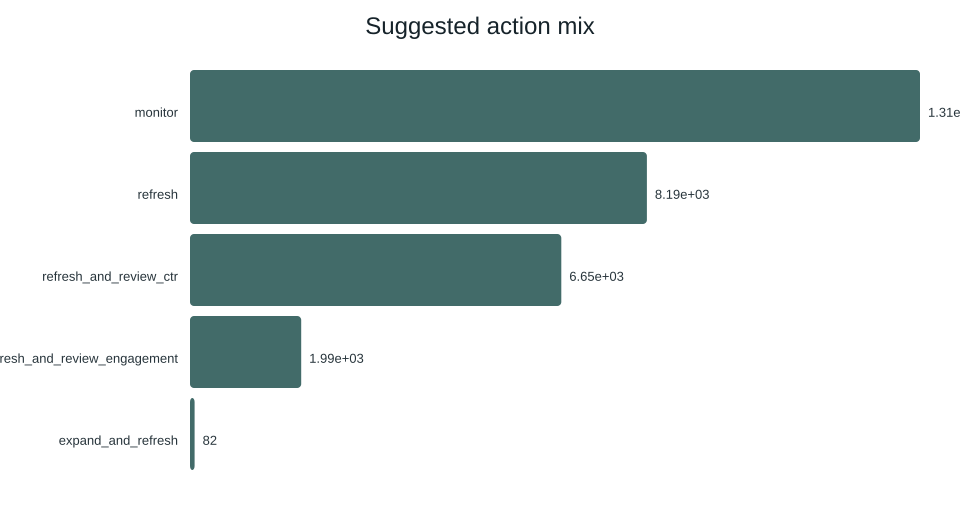

In [ ]:
  from IPython.display import SVG, display
  import os

  chart_dir = "outputs/charts"

  charts = [
      ("top_reason_codes.svg", "Top Reason Codes"),
      ("action_mix.svg", "Action Mix"),
  ]

  for filename, title in charts:
      print(title)
      display(SVG(filename=os.path.join(chart_dir, filename)))

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The following charts were generated directly from the evaluation pipeline and will be included in the deployed research paper.

### 1. Trend Distribution
Shows the distribution of observed content trend outcomes.

### 2. Top Feature Importance
Shows the features that contributed most to the Random Forest model.

### 3. Prediction Confidence Mix
Shows the distribution of model prediction confidence.

### 4. Top Reason Codes
Shows the main reasons associated with the recommended actions.

### 5. Action Mix
Shows the distribution of recommended content actions.

These artifacts support the results and recommendations while keeping the analysis public-safe and based on aggregated model outputs.


Trend Distribution


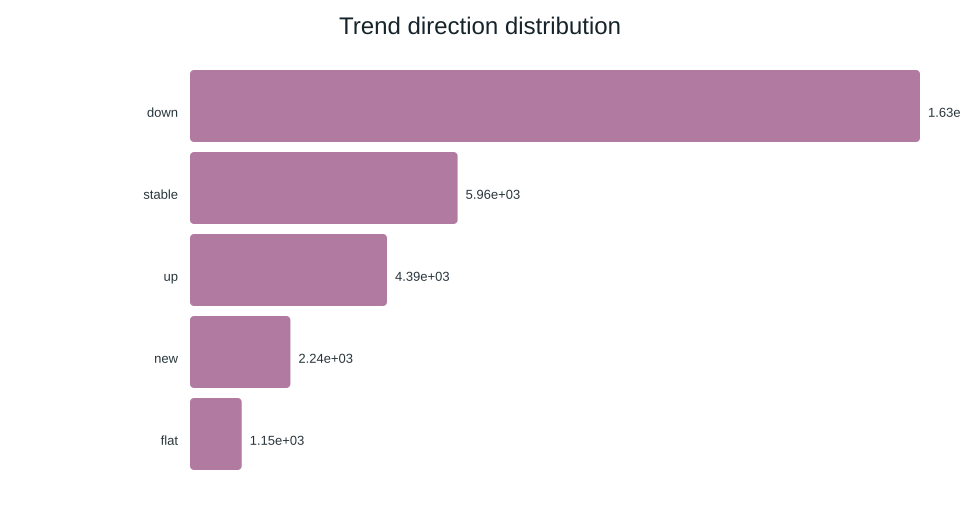


Top Feature Importance


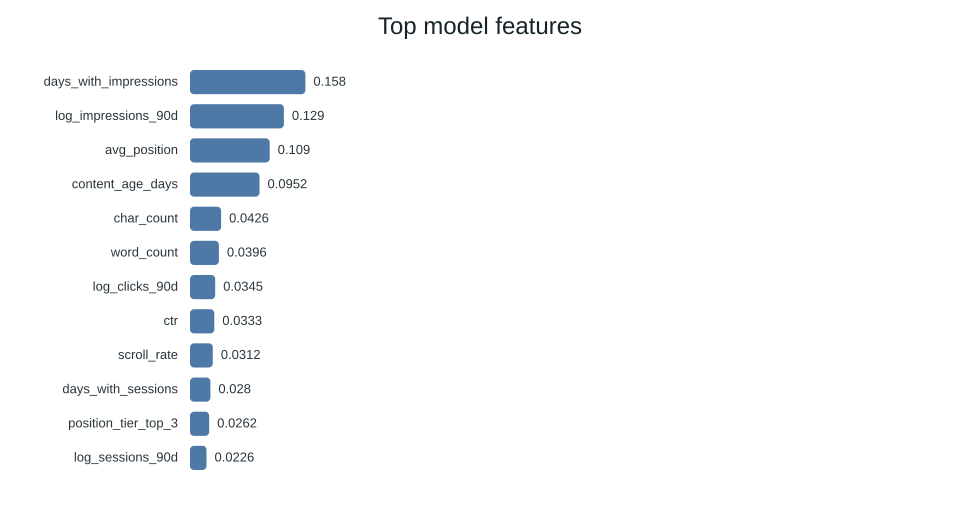


Prediction Confidence Mix


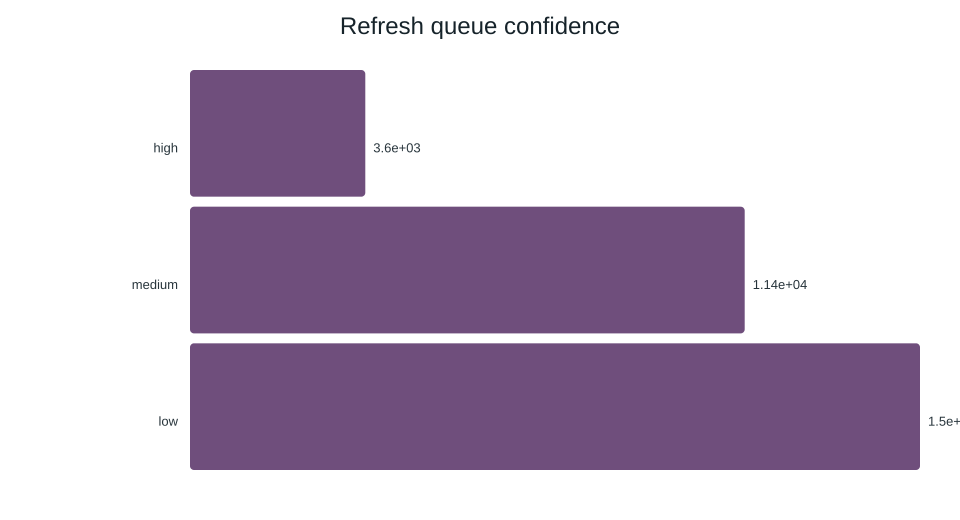


Top Reason Codes


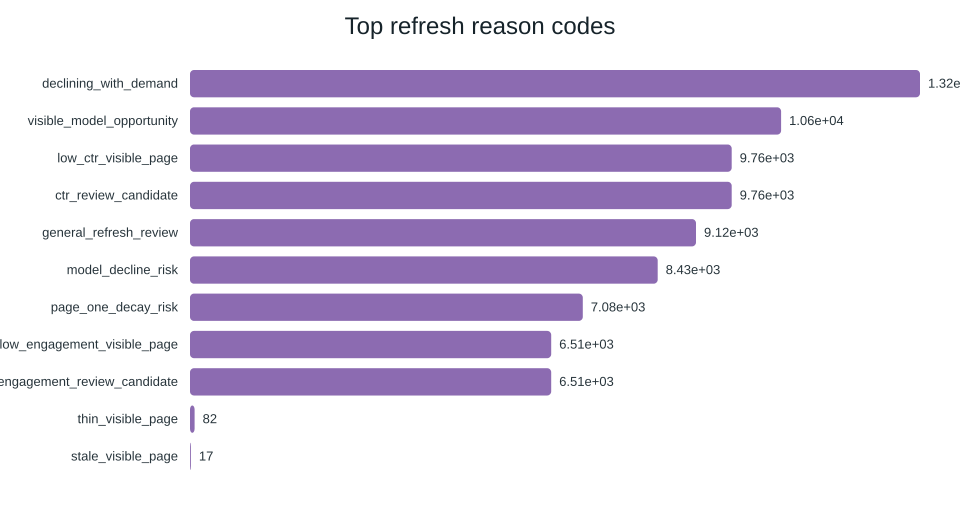


Action Mix


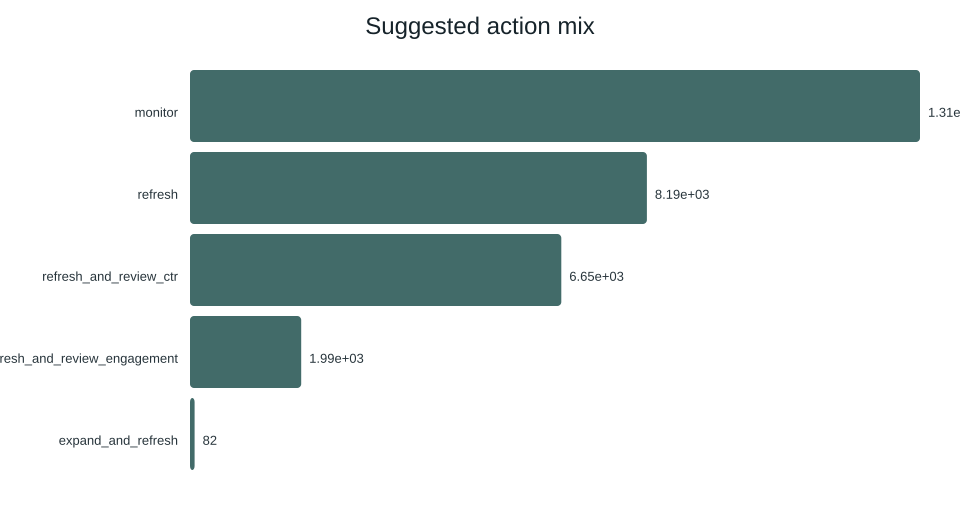

In [ ]:
from IPython.display import SVG, display
import os

chart_dir = "outputs/charts"

charts = [
    ("trend_distribution.svg", "Trend Distribution"),
    ("top_feature_importance.svg", "Top Feature Importance"),
    ("confidence_mix.svg", "Prediction Confidence Mix"),
    ("top_reason_codes.svg", "Top Reason Codes"),
    ("action_mix.svg", "Action Mix"),
]

for filename, title in charts:
    print(f"\n{title}")
    display(SVG(filename=os.path.join(chart_dir, filename)))

# 8. Tell the Story — 5-Minute Demo

## 1. Question

The problem is that content teams may have many pages that need attention, but it is difficult to know which pages should be reviewed first.

My research question was:

**Can machine learning help prioritize content that may be declining?**

The goal is not to automatically change content. The goal is to provide a ranked signal that helps a human decide what to investigate first.

---

## 2. Method

I used 30,000 rows from the FlyRank ML Internship dataset.

The prepared dataset contained **52 model features**, including search-performance, traffic, content, and engagement signals.

I compared four approaches:

1. Transparent baseline
2. Logistic Regression
3. Decision Tree
4. Random Forest

The models were evaluated using a **client-holdout split**.

The main selection metric was **Precision@50**, because the practical goal is to prioritize a small number of pages for human review.

---

## 3. One Chart

### Model Comparison

The most important chart is the model comparison showing Precision@50.

The results were:

| Model | Precision@50 |
|---|---:|
| Baseline | 0.24 |
| Logistic Regression | 0.40 |
| Decision Tree | 0.58 |
| Random Forest | 0.74 |

The Random Forest produced the strongest top-50 prioritization performance.

---

## 4. Honest Result

The Random Forest achieved **0.74 Precision@50** on the held-out test set.

The baseline achieved **0.24 Precision@50**.

In this evaluation, that means 74% of the top 50 Random Forest predictions were positive under the project's declining-content label, compared with 24% for the baseline.

This is a measured result from this evaluation setup.

It should be treated as **directional decision support**, not as a guarantee that a page will decline in the future.

---

## 5. Recommendation

The main recommendation is to use the model as a prioritization tool.

Content teams can:

1. Review the highest-risk pages first.
2. Investigate weak search-performance signals.
3. Check older or less recently updated content.
4. Review engagement-related signals.
5. Make the final content decision through human review.

The model should help decide **what to investigate first**, rather than automatically deciding what content should be changed.

---

## Demo Closing

The key takeaway is that the Random Forest model improved Precision@50 from **0.24 for the baseline to 0.74** on the held-out evaluation set.

The practical outcome is a ranked decision-support workflow that can help focus human attention on potentially declining content.

# Shareable Cuts

## Social Post

I built a machine-learning workflow to help prioritize content that may be declining. Using 30,000 rows and 52 features, I compared a baseline with Logistic Regression, Decision Tree, and Random Forest models using a client-holdout evaluation. Random Forest achieved 0.74 Precision@50 versus 0.24 for the baseline, providing a directional signal for deciding which content to review first.

## Employer-Facing Summary

I built a machine-learning content-prioritization workflow using 30,000 rows from the FlyRank ML Internship dataset. I compared multiple classification models using a client-holdout split, with Random Forest achieving the strongest Precision@50 result of 0.74 versus 0.24 for the baseline. The workflow produces a ranked decision-support signal that can help content teams prioritize pages for human review.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.